<a href="https://colab.research.google.com/github/florina-hash/Loan-Approval/blob/main/LoanApproval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix

In [ ]:
df=pd.read_csv('loan.csv')
print(df)

      Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP001002    Male      No          0      Graduate            No   
1    LP001003    Male     Yes          1      Graduate            No   
2    LP001005    Male     Yes          0      Graduate           Yes   
3    LP001006    Male     Yes          0  Not Graduate            No   
4    LP001008    Male      No          0      Graduate            No   
..        ...     ...     ...        ...           ...           ...   
609  LP002978  Female      No          0      Graduate            No   
610  LP002979    Male     Yes         3+      Graduate            No   
611  LP002983    Male     Yes          1      Graduate            No   
612  LP002984    Male     Yes          2      Graduate            No   
613  LP002990  Female      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849                0.0         NaN           

In [ ]:
print(df.shape)

(480, 13)


In [ ]:
df.drop_duplicates()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
nullcount=df.isnull().sum()
display(nullcount)

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
print(df)

      Loan_ID  Gender Married Dependents     Education Self_Employed  \
1    LP001003    Male     Yes          1      Graduate            No   
2    LP001005    Male     Yes          0      Graduate           Yes   
3    LP001006    Male     Yes          0  Not Graduate            No   
4    LP001008    Male      No          0      Graduate            No   
5    LP001011    Male     Yes          2      Graduate           Yes   
..        ...     ...     ...        ...           ...           ...   
609  LP002978  Female      No          0      Graduate            No   
610  LP002979    Male     Yes         3+      Graduate            No   
611  LP002983    Male     Yes          1      Graduate            No   
612  LP002984    Male     Yes          2      Graduate            No   
613  LP002990  Female      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
1               4583             1508.0       128.0           

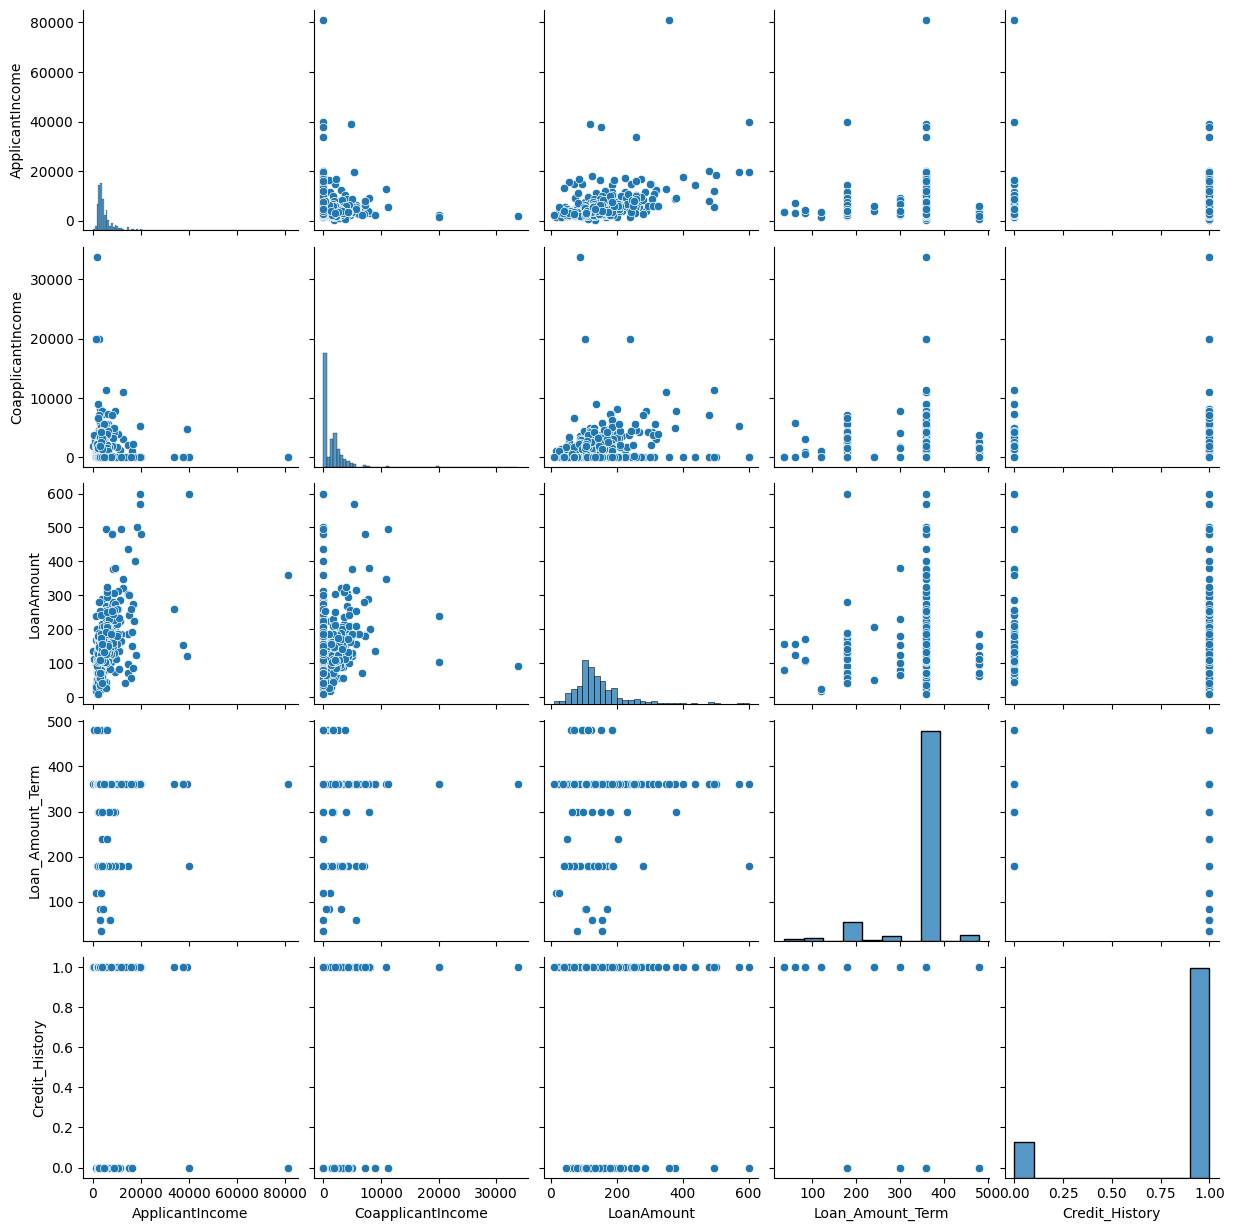

In [ ]:
sns.pairplot(df)
plt.show()

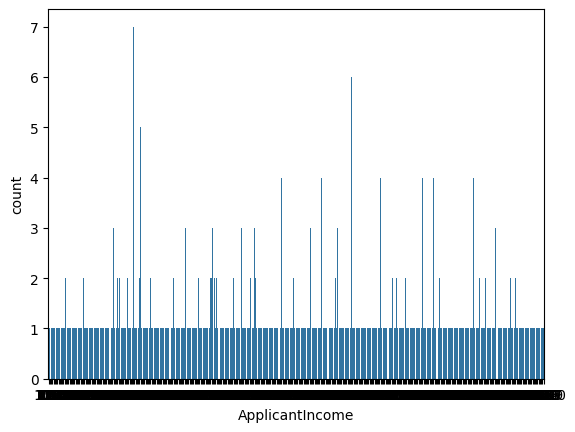

In [ ]:
sns.countplot(x='ApplicantIncome',data=df)
plt.show()

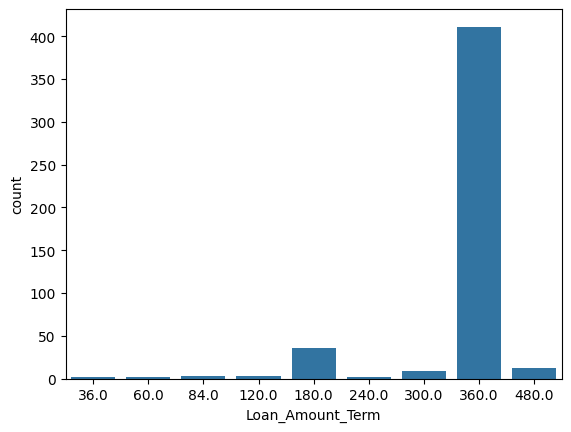

In [ ]:
sns.countplot(x='Loan_Amount_Term',data=df)
plt.show()

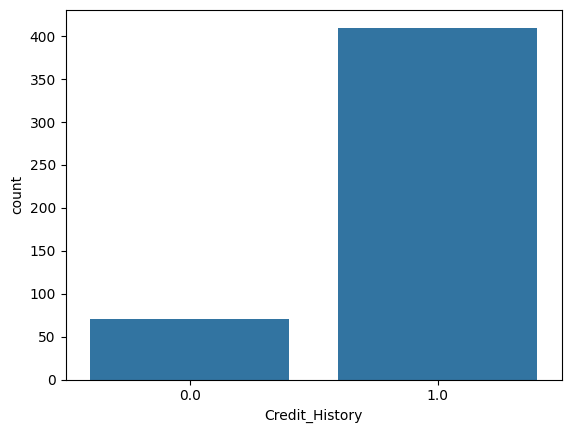

In [ ]:
sns.countplot(x='Credit_History',data=df)
plt.show()

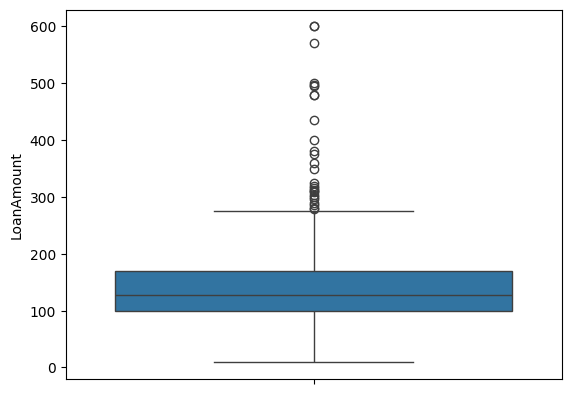

In [ ]:
sns.boxplot(y='LoanAmount',data=df)
plt.show()

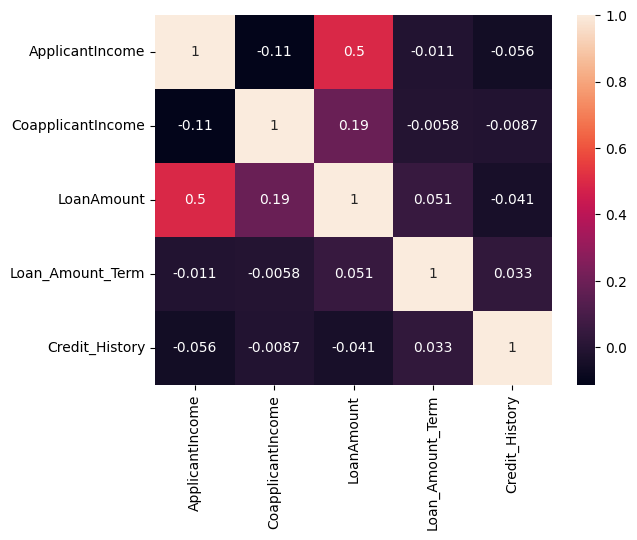

In [ ]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)
plt.show()

In [ ]:
#df.drop("Loan_ID",axis=1,inplace=True)

In [ ]:
le=LabelEncoder()
categorical_col=['Gender','Married','Dependents','Education','Self_Employed','ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History','Property_Area','Loan_Status']
for c in categorical_col:
    df[c]=le.fit_transform(df[c])

In [ ]:
x=df.drop("Loan_Status",axis=1)
y=df['Loan_Status']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import classification_report
yPred=model.predict(x_test)
print("\nAccuracy Score: ",accuracy_score(y_test,yPred))
print("\nConfusion Matrix: ",confusion_matrix(y_test,yPred))
print("\nClassification Report:",classification_report(y_test,yPred))


Accuracy Score:  0.8229166666666666

Confusion Matrix:  [[11 17]
 [ 0 68]]

Classification Report:               precision    recall  f1-score   support

           0       1.00      0.39      0.56        28
           1       0.80      1.00      0.89        68

    accuracy                           0.82        96
   macro avg       0.90      0.70      0.73        96
weighted avg       0.86      0.82      0.79        96



In [ ]:
print("\n--------------------------Loan Prediction----------------------------------------")
try:
  gen=int(input("Gender(Male=1,Female=0): "))
  mar=int(input("Married(Yes=1,No=0): "))
  dep=int(input("Dependents(0-3):"))
  edu=int(input("Education(Graduate=1,Not=0): "))
  s_emp=int(input("Self Employed(Yes=1,No=0): "))
  app_inc=float(input("Applicant Income: "))
  co_app=float(input("Coapplicant Income: "))
  loan_amt=float(input("Loan Amount: "))
  loan_term=float(input("Loan Amount Term(months): "))
  cred_his=int(input("Credit History(1=Good,0=Bad)"))
  propertya=int(input("Property Area(Rural=0,SemiUrban=1,Urban=2): "))
  newData=[[gen,mar,dep,edu,s_emp,app_inc,co_app,loan_amt,loan_term,cred_his,propertya]]
  prediction=model.predict(newData)
  print("\nLoan Approved!"if prediction[0]==1 else "\nLoan Rejected")
except ValueError:
  print("Invalid input. please enter numbers as instructed")


Classification Report:

--------------------------Loan Prediction----------------------------------------
Gender(Male=1,Female=0): 1
Married(Yes=1,No=0): 0
Dependents(0-3):2
Education(Graduate=1,Not=0): 1
Self Employed(Yes=1,No=0): 1
Applicant Income: 6000
Coapplicant Income: 1500
Loan Amount: 108
Loan Amount Term(months): 120
Credit History(1=Good,0=Bad)1
Property Area(Rural=0,SemiUrban=1,Urban=2): 1

Loan Approved!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
